## Replication of Section 4 (Table 2 and 3)

**Paper:** Dealing with Limited Overlap in Estimation of Average Treatment Effects (Crump, Hotz, Imbens, & Mitnik, 2009, Biometrika)

**Data:** Right Heart Catheterization (RHC)
- We use the Right Heart Catheterization (RHC) dataset provided in the R package **ATbounds** (website: https://cran.r-project.org/web/packages/ATbounds/refman/ATbounds.html#RHC, github: https://github.com/ATbounds/ATbounds-r/), which is based on the publicly available RHC data on the Vanderbilt Biostatistics website (https://hbiostat.org/data/).
- The dataset contains 5,735 observations, including 2,184 treated patients and 3,551 control patients, with 72 covariates constructed following Hirano and Imbens (2001).

In [310]:
import pyreadr
import pandas as pd
import statsmodels.api as sm
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

### 1. Data

In [286]:
raw_df = pd.read_csv("data/rhc.csv")
rhc_df = pyreadr.read_r("data/RHC.rda")["RHC"]

#### Data Note

During conducting the replication of Table 3 in Crump et al. (2009), we initially used the *survival* variable provided in the ATbounds RHC dataset. However, the resulting ATE estimates were different from the resulting ATE estimates reported in the paper.

Although the ATbounds documentation describes *survival* as a 30 day survival indicator, the actual *survival* values in RHC.rda match exactly with survival constructed from the raw dataset's *death* variable, rather than with 30 day survival constructed from *dth30*.

Because Crump et al. (2009) use 30 day survival in the section 4, we therefore decide to use:

- **ATbounds RHC dataset:** Treatment and 72 Covariates
- **raw RHC data available from the Vanderbilt Biostatistics website:** Outcome (30 day survival constructed directly from *dth30*)

In [287]:
# two possibilities for survival indicator construction from the raw data
survival_30 = (raw_df["dth30"] == "No").astype(int)
survival_death = (raw_df["death"] == "No").astype(int)
# treatment variable from the raw data
raw_treatment = (raw_df["swang1"] == "RHC").astype(int)

# check the row ordering is consistent across the raw and ATbounds data
print("Treatment mismatch:", 
      np.sum(raw_treatment.to_numpy() != rhc_df["RHC"].to_numpy()))

# compare the ATbounds survival variable with the two possibilities
print("Mismatch with 30 day survival:",
      np.sum(survival_30.to_numpy() != rhc_df["survival"].to_numpy()))
print("Mismatch with raw death based survival:",
      np.sum(survival_death.to_numpy() != rhc_df["survival"].to_numpy()))

Treatment mismatch: 0
Mismatch with 30 day survival: 1804
Mismatch with raw death based survival: 0


- The row ordering is identical across the raw and ATbounds data 
- The ATbounds' *survival* variable differs from the raw 30 day survival indicator for 1,804 units, but matches the raw death based survival indicator exactly
- Thus, the 30 day survival outcome variable for the replication should be reconstructed from raw dataset's *dth30*

In [288]:
# reconstruct the 30 day survival outcome variable
rhc_df["survival30"] = (raw_df["dth30"] == "No").astype(int).to_numpy()

In [289]:
print("data shape:", rhc_df.shape)
rhc_df.head()

data shape: (5735, 75)


,survival,RHC,age,edu,cardiohx,chfhx,dementhx,psychhx,chrpulhx,renalhx,...,dnr1_Yes,sex_Female,cat2_Cirrhosis,cat2_Colon_Cancer,cat2_Coma,cat2_Lung_Cancer,cat2_MOSF_Malignancy,cat2_MOSF_Sepsis,wt0,survival30
0,1.0,0.0,70.25098,12.000000,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,1.0,78.17896,12.000000,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,1.0,1.0,46.09198,14.069916,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
3,0.0,0.0,75.33197,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,1.0,67.90997,9.945259,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [290]:
# check treatment & control
rhc_df["RHC"].value_counts()   # treatment and control group sizes match those reported in Crump et al. (2009)

RHC
0.0    3551
1.0    2184
Name: count, dtype: int64

In [291]:
Y = rhc_df["survival30"]
W = rhc_df["RHC"]   # treatment indicator: 1 if treated, 0 if control
X = rhc_df.drop(columns=["survival", "survival30", "RHC"])

### 2. Table 2. Subsample Sizes for Right Heart Catheterization Data

For each individual $i$, the propensity score is defined as

$$
e(X_i) = P(W_i = 1 \mid X_i),
$$

where $W_i$ is the treatment indicator and $X_i$ is the vector of 72 covariates

In [292]:
# add an intercept (for β0)
X_logit = sm.add_constant(X)

# estimate propensity scores
# using logistic regression
ps_model = sm.GLM(W, X_logit, family=sm.families.Binomial())   # P(Wi​ = 1 ∣ Xi​)
ps_fit = ps_model.fit()

ps_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    RHC   No. Observations:                 5735
Model:                            GLM   Df Residuals:                     5662
Model Family:                Binomial   Df Model:                           72
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2957.9
Date:                Mon, 28 Sep 2026   Deviance:                       5915.9
Time:                        02:17:46   Pearson chi2:                 5.62e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2572
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             20.6161      3.157      6.530      0.000      14.428      26.804
age                               -0.0062      0.003     -2.103      0.035      -0.012      -0.000
edu                                0.0243      0.012      2.065      0.039       0.001       0.047
cardiohx                           0.0463      0.096      0.481      0.630      -0.142       0.235
chfhx                              0.0996      0.105      0.946      0.344      -0.107       0.306
dementhx                          -0.4190      0.122     -3.427      0.001      -0.659      -0.179
psychhx                           -0.4299      0.140     -3.077      0.002      -0.704      -0.156
chrpulhx                           0.0051      0.102      0.050      0.960      -0.194       0.204
renalhx                           -0.2940      0.183     -1.609      0.108      -0.652       0.064
liverhx                            0.0956      0.203      0.472      0.637      -0.302       0.493
gibledhx                          -0.1716      0.231     -0.744      0.457      -0.624       0.280
malighx                           -0.0758      0.389     -0.195      0.845      -0.838       0.686
immunhx                            0.0398      0.075      0.529      0.597      -0.108       0.187
transhx                            0.5006      0.101      4.972      0.000       0.303       0.698
amihx                              0.1454      0.177      0.820      0.412      -0.202       0.493
das2d3pc                          -0.0008      0.007     -0.120      0.905      -0.014       0.012
surv2md1                          -2.5998      0.385     -6.753      0.000      -3.354      -1.845
aps1                               0.0011      0.003      0.354      0.724      -0.005       0.007
scoma1                            -0.0045      0.002     -2.730      0.006      -0.008      -0.001
wtkilo1                            0.0113      0.002      6.410      0.000       0.008       0.015
temp1                             -0.0363      0.020     -1.802      0.072      -0.076       0.003
meanbp1                           -0.0060      0.001     -5.807      0.000      -0.008      -0.004
resp1                             -0.0203      0.003     -7.729      0.000      -0.025      -0.015
hrt1                               0.0055      0.001      6.115      0.000       0.004       0.007
pafi1                             -0.0045      0.000    -12.854      0.000      -0.005      -0.004
paco21                            -0.0272      0.004     -7.311      0.000      -0.034      -0.020
ph1                               -1.8313      0.390     -4.698      0.000      -2.595      -1.067
wblc1                              0.0007      0.003      0.261      0.794      -0.005       0.006
hema1         

In [293]:
# predicted propensity score
rhc_df["pscore"] = ps_fit.predict(X_logit)
rhc_df["pscore"].describe()   # check the summary statistics

count    5735.000000
mean        0.380820
std         0.251944
min         0.002234
25%         0.162288
50%         0.344355
75%         0.577726
max         0.988794
Name: pscore, dtype: float64

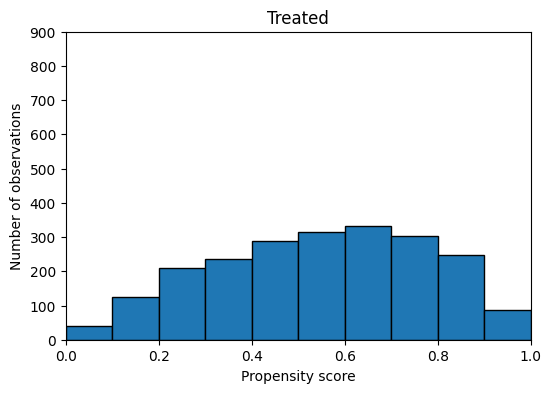

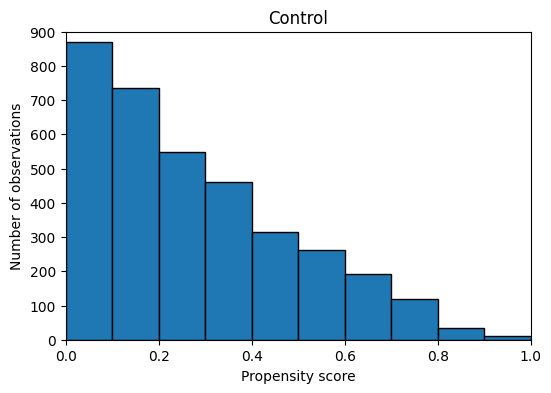

In [312]:
# create figure 1
# histogram - propensity scores vs number of obs. for treated and control

# treated
plt.figure(figsize=(6, 4))
plt.hist(rhc_df.loc[rhc_df["RHC"] == 1, "pscore"],
         bins=np.arange(0, 1.1, 0.1),
         edgecolor="black")
plt.xlabel("Propensity score")
plt.ylabel("Number of observations")
plt.title("Treated")
plt.xlim(0, 1)
plt.ylim(0, 900)
plt.show()

# control
plt.figure(figsize=(6, 4))
plt.hist(rhc_df.loc[rhc_df["RHC"] == 0, "pscore"],
         bins=np.arange(0, 1.1, 0.1),
         edgecolor="black")
plt.xlabel("Propensity score")
plt.ylabel("Number of observations")
plt.title("Control")
plt.xlim(0, 1)
plt.ylim(0, 900)
plt.show()

Crump et al. (2009) classified observations into three groups based on the estimated propensity score, then report the number of treated and control observations in each propensity score range :

$$
(i)\;
\hat e(X_i) < 0.1
$$

$$
(ii)\;
0.1 \leq \hat e(X_i) \leq 0.9
$$

$$
(iii)\;
\hat e(X_i) > 0.9
$$

In [294]:
# classify data into three groups by estimated propensity score
rhc_df["ps_group"] = np.select([rhc_df["pscore"] < 0.1, rhc_df["pscore"] <= 0.9], 
                               ["< 0.1", "0.1 - 0.9"], 
                               default="> 0.9")

# create table 2
table2 = pd.crosstab(rhc_df["RHC"], 
                     rhc_df["ps_group"])

# make table design same as the paper
table2 = table2[["< 0.1", "0.1 - 0.9", "> 0.9"]]   # reorder columns
table2.index = ["Controls", "Treated"]   # rename rows
table2["All"] = table2.sum(axis=1)   # add row total
table2.loc["All"] = table2.sum(axis=0)   # add column total

# print result
table2   # result is same with those reported in Crump et al. (2009)

ps_group,< 0.1,0.1 - 0.9,> 0.9,All
Controls,870,2671,10,3551
Treated,40,2057,87,2184
All,910,4728,97,5735


### 3. Optimal Trimming Cut-off

Based on the estimated propensity score, now we should calculate the optimal cut-off value α in Corollary 1.

The optimal sample is defined as

$$
\hat{A}
=
\left\{
X_i :
\hat{\alpha}
\leq
\hat{e}(X_i)
\leq
1-\hat{\alpha}
\right\}.
$$

Crump et al. (2009) report an estimated optimal cut-off is

$$
\hat{\alpha}=0.1026
$$

In [295]:
ps = rhc_df["pscore"].to_numpy()

def cutoff_condition(alpha, ps):

    # select observations with propensity scores in [alpha, 1 - alpha]
    keep = (ps >= alpha) & (ps <= 1 - alpha)

    # compute left-hand side of the cut-off criterion
    lhs = 1 / (alpha * (1 - alpha))
    # compute right-hand side of the cut-off criterion
    rhs = 2 * np.mean(1 / (ps[keep] * (1 - ps[keep])))
    
    return lhs <= rhs

In [296]:
# candidate cut-off values between 0 and 0.5
alpha_candidates = np.linspace(0.0001, 0.4999, 100000)

# find the smallest valid alpha
for alpha in alpha_candidates:

    # check cut-off criterion
    if cutoff_condition(alpha, ps):
        alpha_hat = alpha   # save the first valid alpha
        break   # break when the smallest valid alpha is found

# print result
print(f"Estimated optimal lower cut-off: {alpha_hat:.4f}")
print(f"Estimated optimal upper cut-off: {1 - alpha_hat:.4f}")

Estimated optimal lower cut-off: 0.1029
Estimated optimal upper cut-off: 0.8971


The estimated optimal cut-off is $\hat{\alpha}=0.1029$, which is very close to the value of $0.1026$ reported in Crump et al. (2009).

### 4. Table 3. Estimates for average treatment effects in right heart catheterization study

Following Table 3 in Crump et al. (2009), the paper considers three samples:

(i) the full sample

$$
\mathcal{S}_{\mathrm{full}}
=
\{i : 1 \leq i \leq N\}.
$$

(ii) the set of units with $\hat{e}(X_i) ∈ [0.1, 0.9]$, based on the 0.1 rule-of-thumb

$$
\mathcal{S}_{0.1}
=
\left\{
i :
0.1
\leq
\hat e(X_i)
\leq
0.9
\right\}.
$$

(iii) the optimal set with $\hat{e}(X_i)$

$$
\mathcal{S}_{\mathrm{opt}}
=
\left\{
i :
\hat{\alpha}
\leq
\hat e(X_i)
\leq
1-\hat{\alpha}
\right\}.
$$

In [297]:
# full sample
full_sample = rhc_df.copy()
# sample based on the 0.1 rule-of-thumb
rule_sample = rhc_df[(rhc_df["pscore"] >= 0.1) & (rhc_df["pscore"] <= 0.9)].copy()
# sample based on estimated optimal cut-off
optimal_sample = rhc_df[(rhc_df["pscore"] >= alpha_hat) & (rhc_df["pscore"] <= 1 - alpha_hat)].copy()
# sample based on optimal cut-off using paper cut-off
paper_a = 0.1026
optimal_sample_paper = rhc_df[(rhc_df["pscore"] >= paper_a) & (rhc_df["pscore"] <= 1 - paper_a)].copy()

# check sample size
print("Full sample:", len(full_sample))
print("Rule-of-thumb cut-off sample:", len(rule_sample))
print("Optimal cut-off sample:", len(optimal_sample))
print("Optimal cut-off sample using paper cut-off:", len(optimal_sample_paper))

Full sample: 5735
Rule-of-thumb cut-off sample: 4728
Optimal cut-off sample: 4699
Optimal cut-off sample using paper cut-off: 4704


In [298]:
# reestimate propensity scores
def reestimate_propensity_score(df):

    # treatment indicator
    W_sample = df["RHC"]
    # covariates
    X_sample = df.drop(columns=["survival", "survival30", "RHC", "pscore", "ps_group"], errors="ignore")

    # add an intercept (for β0)
    X_sample_logit = sm.add_constant(X_sample)

    # estimate propensity scores
    # using logistic regression
    ps_sample_model = sm.GLM(W_sample, X_sample_logit, family=sm.families.Binomial())
    ps_sample_fit = ps_sample_model.fit()

    # predicted propensity score within the sample
    df["pscore_re"] = ps_sample_fit.predict(X_sample_logit)

    return df

In [299]:
full_sample = reestimate_propensity_score(full_sample)
rule_sample = reestimate_propensity_score(rule_sample)
optimal_sample = reestimate_propensity_score(optimal_sample)
optimal_sample_paper = reestimate_propensity_score(optimal_sample_paper)

#### Table 3 - Average Treatment Effect Replication

**Average Treatment Effect Estimation**

Estimate the average treatment effect using a version of the Horvitz–Thompson estimator:

$$
\hat{\tau}
=
\frac{
\sum_{i=1}^{N}
\frac{W_i Y_i}{\hat{e}(X_i)}
}{
\sum_{i=1}^{N}
\frac{W_i}{\hat{e}(X_i)}
}
-
\frac{
\sum_{i=1}^{N}
\frac{(1-W_i)Y_i}{1-\hat{e}(X_i)}
}{
\sum_{i=1}^{N}
\frac{1-W_i}{1-\hat{e}(X_i)}
}.
$$

- $W_i$ is the treatment indicator
- $Y_i$ is the 30 day survival outcome
- $\hat{e}(X_i)$ is the propensity score reestimated within each selected sample

In [300]:
# compute ATE (a version of the Horvitz–Thompson estimator)
def estimate_ate(df):

    # treatment indicator
    W = df["RHC"].to_numpy()
    # outcome
    Y = df["survival30"].to_numpy()
    # reestimated propensity score
    ps = df["pscore_re"].to_numpy()

    # weighted mean outcome for treatment
    treated_mean = np.sum(W * Y / ps) / np.sum(W / ps)
    # weighted mean outcome for control
    control_mean = np.sum((1 - W) * Y / (1 - ps)) / np.sum((1 - W) / (1 - ps))
    # ATE
    ate = treated_mean - control_mean

    return ate

In [301]:
full_ate = estimate_ate(full_sample)
rule_ate = estimate_ate(rule_sample)
optimal_ate = estimate_ate(optimal_sample)
optimal_paper_ate = estimate_ate(optimal_sample_paper)

print(f"Full sample ATE: {full_ate:.4f}")
print(f"Rule-of-thumb cut-off sample ATE: {rule_ate:.4f}")
print(f"Optimal cut-off sample ATE: {optimal_ate:.4f}")
print(f"Optimal cut-off sample ATE using paper cut-off: {optimal_paper_ate:.4f}")

Full sample ATE: -0.0593
Rule-of-thumb cut-off sample ATE: -0.0590
Optimal cut-off sample ATE: -0.0599
Optimal cut-off sample ATE using paper cut-off: -0.0599


#### Why not exactly match the paper's optimal sample ATE?

In [302]:
# number of units using the paper cut-off
paper_optimal_n = ((rhc_df["pscore"] >= 0.1026) & (rhc_df["pscore"] <= 0.8974)).sum()
# number of units using our estimated cut-off
estimated_optimal_n = ((rhc_df["pscore"] >= alpha_hat) &(rhc_df["pscore"] <= 1 - alpha_hat)).sum()

print("Optimal sample size using paper cut-off:", paper_optimal_n)
print("Optimal sample size using our estimated cut-off:", estimated_optimal_n)

Optimal sample size using paper cut-off: 4704
Optimal sample size using our estimated cut-off: 4699


Even when we use the paper's optimal cut-off (0.1026), the estimated ATE is -0.0599, which is very close to, but does not exactly same with the paper's value of -0.0601. This suggests that the small difference in the optimal sample ATE seems not due to the difference between our estimated optimal cut-off (0.1029) and the paper's cut-off (0.1026). In fact, only 5 units are different between the two samples. 

There might be some possible reasons for the remaining difference. First, even if we use the same cut-off as the paper, we may not select exactly the same patients because our estimated propensity scores can be slightly different from those estimated by the authors. Also, after selecting the sample, we re-estimate the propensity scores within that sample, and even small differences in these scores can change the weights used to calculate the ATE and lead to a slightly different estimate.

#### Table 3 - Standard Error Replication (Bootstrap)

Following Crump et al. (2009), standard errors are estimated using bootstrap replications within each selected sample.

First, simply calculate the standard deviation of the $B$ bootstrap replications:

$$
SE(1) = SD\left(\hat{\tau}^{*(1)}, \ldots, \hat{\tau}^{*(B)}\right).
$$

Second, given the ordered $B$ bootstrap estimates, take the difference between the $0.95 × B$ and the $0.05 × B$ bootstrap estimates and divided this difference by $2 × 1.645$ to obtain an estimate for the standard error:

$$
SE(2)
=
\frac{
\hat{\tau}^{*}_{0.95}
-
\hat{\tau}^{*}_{0.05}
}{
2 \times 1.645
}.
$$

$B=50{,}000$ bootstrap

In [303]:
# save names of the 72 covariates
X_cols = X.columns.tolist()

In [304]:
# run bootstrap one time (return only one ATE)
def bootstrap_ate_one_time(df, seed):
    
    # bootstrap sample with replacement
    boot_df = df.sample(n=len(df), replace=True, random_state=seed)

    # treatment indicator
    W_boot = boot_df["RHC"]
    # covariates
    X_boot = boot_df[X_cols]
    # add an intercept (for β0)
    X_boot_logit = sm.add_constant(X_boot)

    # reestimate propensity scores
    # using logistic regression
    propensity_model = sm.GLM(W_boot, X_boot_logit, family=sm.families.Binomial())
    propensity_fit = propensity_model.fit()

    # predicted new propensity score within the bootstrap sample
    ps_boot = propensity_fit.predict(X_boot_logit).to_numpy()

    # treatment indicator
    W = boot_df["RHC"].to_numpy()
    # outcome
    Y = boot_df["survival30"].to_numpy()

    # weighted mean outcome for treatment
    treated_mean = (np.sum(W * Y / ps_boot) 
                    / np.sum(W / ps_boot))

    # weighted mean outcome for control
    control_mean = (np.sum((1 - W) * Y / (1 - ps_boot))
                    / np.sum((1 - W) / (1 - ps_boot)))

    # bootstrap ATE
    ate_boot = treated_mean - control_mean

    return ate_boot

In [305]:
# run bootstrap 50,000 time (return 50,000 ATE)
def bootstrap_ate(df, B=50000, seed=6165, n_jobs=8):

    # create random number generator
    rng = np.random.default_rng(seed)
    # generate independent seeds for bootstrap replications
    bootstrap_seeds = rng.integers(0, 2**32 - 1, size=B)

    # run bootstrap replications in parallel
    bootstrap_ates = Parallel(
            n_jobs=n_jobs, verbose=10
        )(
            delayed(bootstrap_ate_one_time)(df, s)
            for s in bootstrap_seeds
        )

    bootstrap_ates = np.array(bootstrap_ates)   # list -> array

    return np.array(bootstrap_ates)

# # CODE BEFORE USING PARALLEL
# # list for save bootstrap ATE estimates
# bootstrap_ates = []

# # repeat the bootstrap 50,000 times
# for b in tqdm(range(B), desc=desc):
#     ate_boot = bootstrap_ate_one_time(df)   # estimate ATE
#     bootstrap_ates.append(ate_boot)   # save bootstrap estimate into the bootstrap_ates list

# bootstrap_ates = np.array(bootstrap_ates)   # list -> array

In [306]:
# full sample
boot_full = bootstrap_ate(full_sample)

# rule-of-thumb sample
boot_rule = bootstrap_ate(rule_sample)

# optimal sample using our estimated cut-off
boot_optimal = bootstrap_ate(optimal_sample)

# optimal sample using the paper's cut-off
boot_optimal_paper = bootstrap_ate(optimal_sample_paper)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    1.2s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    1.6s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:    2.0s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:    2.2s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:    2.5s
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:    2.8s
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:    3.1s
/Users/hayleyshin/miniforge3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=8)]: Done 112 tasks      | elaps

In [307]:
# compute SE(1) and SE(2) in table 3
def bootstrap_se(bootstrap_ates):

    # SE(1)
    # sd of the bootstrap ATE estimates
    se1 = np.std(bootstrap_ates, ddof=1)
    
    # 5th and 95th percentiles of the bootstrap distribution
    q05 = np.quantile(bootstrap_ates, 0.05)   # 5th percentile -> μ − 1.645σ
    q95 = np.quantile(bootstrap_ates, 0.95)   # 95th percentile -> μ + 1.645σ

    # SE(2)
    # percentile based standard error
    se2 = (q95 - q05) / (2 * 1.645)
    
    return se1, se2

In [308]:
# compute SE(1) and SE(2) for 
# 1) full sample
# 2) rule-of-thumb cut-off sample
# 3) optimal sample (our estimated cut-off)
# 4) optimal sample (paper cut-off)
se1_full, se2_full = bootstrap_se(boot_full)
se1_rule, se2_rule = bootstrap_se(boot_rule)
se1_optimal, se2_optimal = bootstrap_se(boot_optimal)
se1_optimal_paper, se2_optimal_paper = bootstrap_se(boot_optimal_paper)

# check results
print(f"Full sample: "
      f"SE(1) = {se1_full:.4f}, "
      f"SE(2) = {se2_full:.4f}")

print(f"Rule-of-thumb cut-off sample: "
      f"SE(1) = {se1_rule:.4f}, "
      f"SE(2) = {se2_rule:.4f}")

print(f"Optimal sample using our estimated cut-off: "
      f"SE(1) = {se1_optimal:.4f}, "
      f"SE(2) = {se2_optimal:.4f}")

print(f"Optimal sample using paper cut-off: "
      f"SE(1) = {se1_optimal_paper:.4f}, "
      f"SE(2) = {se2_optimal_paper:.4f}")

Full sample: SE(1) = 0.0166, SE(2) = 0.0165
Rule-of-thumb cut-off sample: SE(1) = 0.0143, SE(2) = 0.0143
Optimal sample using our estimated cut-off: SE(1) = 0.0144, SE(2) = 0.0144
Optimal sample using paper cut-off: SE(1) = 0.0143, SE(2) = 0.0143


### Extension 2

#### Smooth boundary around 0.1 and 0.9

In [313]:
def smoothstep(x):
    
    # input -> NumPy array
    x = np.asarray(x)

    # smooth transition (0 if x <= 0; 1 if x >= 1)
    # cubic smoothstep between 0 and 1
    return np.where(x <= 0, 0, np.where(x >= 1, 1, 3 * x**2 - 2 * x**3))

In [314]:
def boundary_smooth_weights(e, delta, alpha1=0.10, alpha2=0.90):
    
    # smooth transition from 0 to 1 around the lower cutoff
    left = smoothstep((e - (alpha1 - delta)) 
                      / (2 * delta))

    # smooth transition from 1 to 0 around the upper cutoff
    right = smoothstep(((alpha2 + delta) - e) 
                       / (2 * delta))

    # combine the lower and upper boundary weights
    w = left * right
    
    return w

In [315]:
# compute weighted ATE
def estimate_weighted_ate(df, w):

    # treatment indicator
    W = df["RHC"].to_numpy()
    # outcome
    Y = df["survival30"].to_numpy()
    # estimated propensity scores
    e = df["pscore"].to_numpy()

    # weighted mean outcome for treatment
    treated_mean = (np.sum(W * Y * w / e)
                    / np.sum(W * w / e))

    # weighted mean outcome for control
    control_mean = (np.sum((1 - W) * Y * w / (1 - e))
                    / np.sum((1 - W) * w / (1 - e)))
    # weighted ATE
    ate = treated_mean - control_mean

    return ate

In [316]:
# estimated propensity scores from the RHC data
e = rhc_df["pscore"].to_numpy()

In [321]:
# compare ATE estimates for different smooth boundary widths
for delta in [0.005, 0.01, 0.025, 0.05]:

    # construct smooth boundary weights
    w = boundary_smooth_weights(e, delta=delta)

    # estimate weighted ATE
    ate = estimate_weighted_ate(rhc_df, w)

    # result
    print(f"Smooth boundary (delta={delta:.3f}): {ate:.4f}")

Smooth boundary (delta=0.005): -0.0589
Smooth boundary (delta=0.010): -0.0596
Smooth boundary (delta=0.025): -0.0623
Smooth boundary (delta=0.050): -0.0645


In [328]:
# only using two smooth boundary specifications

# smooth boundary: delta = 0.01
w_delta_010 = boundary_smooth_weights(e, delta=0.01)
ate_delta_010 = estimate_weighted_ate(rhc_df, w_delta_010)

# smooth boundary: delta = 0.05
w_delta_050 = boundary_smooth_weights(e, delta=0.05)
ate_delta_050 = estimate_weighted_ate(rhc_df, w_delta_050)

#### Overlap weighting / smooth weighting

In [319]:
# construct smooth overlap weights
w_smooth = e * (1 - e)

# estimate weighted ATE
ate_smooth = estimate_weighted_ate(rhc_df, w_smooth)

# Display result
print(f"Smooth weighting: {ate_smooth:.4f}")

Smooth weighting: -0.0654


#### Standard Error (Bootstrap)

In [322]:
# run bootstrap one time (return only one weighted ATE)
def bootstrap_weighted_ate_one_time(df, seed, method, delta=None):

    # bootstrap sample with replacement
    boot_df = df.sample(n=len(df), replace=True, random_state=seed)

    # treatment indicator
    W_boot = boot_df["RHC"]
    # covariates
    X_boot = boot_df[X_cols]
    # add an intercept (for β0)
    X_boot_logit = sm.add_constant(X_boot)

    # reestimate propensity scores
    # using logistic regression
    propensity_model = sm.GLM(W_boot, X_boot_logit, family=sm.families.Binomial())
    propensity_fit = propensity_model.fit()

    # predicted new propensity score within the bootstrap sample
    ps_boot = propensity_fit.predict(X_boot_logit).to_numpy()

    # construct weights according to the method
    if method == "boundary":
        w_boot = boundary_smooth_weights(ps_boot, delta=delta)

    elif method == "smooth":
        w_boot = ps_boot * (1 - ps_boot)

    else:
        raise ValueError("method must be boundary or smooth")

    # treatment indicator
    W = boot_df["RHC"].to_numpy()
    # outcome
    Y = boot_df["survival30"].to_numpy()
    
    # weighted mean outcome for treatment
    treated_mean = (np.sum(W * Y * w_boot / ps_boot)
                    / np.sum(W * w_boot / ps_boot))

    # weighted mean outcome for control
    control_mean = (np.sum((1 - W) * Y * w_boot / (1 - ps_boot))
                    / np.sum((1 - W) * w_boot / (1 - ps_boot)))

    # bootstrap weighted ATE
    ate_boot = treated_mean - control_mean

    return ate_boot

In [323]:
# run bootstrap 50,000 time (return 50,000 weighted ATE)
def bootstrap_weighted_ate(df, method, delta=None, B=50000, seed=6165, n_jobs=8):

    # create random number generator
    rng = np.random.default_rng(seed)
    # generate independent seeds for bootstrap replications
    bootstrap_seeds = rng.integers(0, 2**32 - 1, size=B)

    # run bootstrap replications in parallel
    bootstrap_ates = Parallel(
            n_jobs=n_jobs, verbose=10
        )(
            delayed(bootstrap_weighted_ate_one_time)(df, s, method, delta)
            for s in bootstrap_seeds
        )

    bootstrap_ates = np.array(bootstrap_ates)   # list -> array

    return np.array(bootstrap_ates)

In [330]:
# smooth boundary: delta = 0.01
boot_delta_010 = bootstrap_weighted_ate(rhc_df, method="boundary", delta=0.01)

# smooth boundary: delta = 0.05
boot_delta_050 = bootstrap_weighted_ate(rhc_df, method="boundary", delta=0.05)

# smooth overlap weighting
boot_smooth = bootstrap_weighted_ate(rhc_df, method="smooth")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.5s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    1.7s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    1.9s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.1s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:    2.4s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:    2.7s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:    3.0s
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:    3.3s
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:    3.6s
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:    3.9s
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:    4.2s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:    4.5s
/Users/hayleyshin/miniforge3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopp

In [331]:
# compute SE(1) and SE(2) for 
# 1) smooth boundary: delta = 0.01
# 2) smooth boundary: delta = 0.05
# 3) smooth overlap weighting
se1_delta_010, se2_delta_010 = bootstrap_se(boot_delta_010)
se1_delta_050, se2_delta_050 = bootstrap_se(boot_delta_050)
se1_smooth, se2_smooth = bootstrap_se(boot_smooth)

# check results
print(f"Rule-of-thumb cut-off sample: "
      f"ATE = {rule_ate:.4f}, "
      f"SE(1) = {se1_rule:.4f}, "
      f"SE(2) = {se2_rule:.4f}")

print(f"Smooth boundary (delta=0.01): "
      f"ATE = {ate_delta_010:.4f}, "
      f"SE(1) = {se1_delta_010:.4f}, "
      f"SE(2) = {se2_delta_010:.4f}")

print(f"Smooth boundary (delta=0.05): "
      f"ATE = {ate_delta_050:.4f}, "
      f"SE(1) = {se1_delta_050:.4f}, "
      f"SE(2) = {se2_delta_050:.4f}")

print(f"Smooth weighting: "
      f"ATE = {ate_smooth:.4f}, "
      f"SE(1) = {se1_smooth:.4f}, "
      f"SE(2) = {se2_smooth:.4f}")

Rule-of-thumb cut-off sample: ATE = -0.0590, SE(1) = 0.0143, SE(2) = 0.0143
Smooth boundary (delta=0.01): ATE = -0.0596, SE(1) = 0.0147, SE(2) = 0.0147
Smooth boundary (delta=0.05): ATE = -0.0645, SE(1) = 0.0141, SE(2) = 0.0141
Smooth weighting: ATE = -0.0654, SE(1) = 0.0134, SE(2) = 0.0133


#### Effective Sample Size (ESS) and Total Variation Distance (TVD)

In [332]:
def ess_ratio(w):

    # effective sample size
    ess = (np.sum(w) ** 2) / np.sum(w ** 2)

    # express ESS as a proportion of the original sample size
    ess_ratio = ess / len(w)

    return ess_ratio

In [333]:
def tv_distance(e, w, breaks=np.arange(0, 1.05, 0.05)):

    # assign propensity scores to bins
    bins = pd.cut(e, bins=breaks, include_lowest=True)

    # original proportion of observations in each bin
    p_original = (pd.Series(bins).value_counts(sort=False).to_numpy() / len(e))

    # total weight in each propensity-score bin
    weighted_counts = (pd.DataFrame({"bin": bins, "w": w}).groupby("bin", observed=False)["w"].sum().to_numpy())

    # convert weighted counts to weighted proportions
    p_weighted = (weighted_counts
                  / np.sum(weighted_counts))

    # total variation distance
    TVD = 0.5 * np.sum(np.abs(p_original - p_weighted))

    return TVD

In [334]:
# full sample: every observation receives weight = 1
w_full = np.ones(len(e))
# rule-of-thumb cutoff (hard trimming)
w_rule = ((e >= 0.10) & (e <= 0.90)).astype(int)
# estimated optimal cutoff (hard trimming)
w_opt = ((e >= alpha_hat) & (e <= 1 - alpha_hat)).astype(int)

In [335]:
# compute ESS (effective sample size) ratios
ESS_full = ess_ratio(w_full)
ESS_rule = ess_ratio(w_rule)
ESS_opt = ess_ratio(w_opt)
ESS_delta_010 = ess_ratio(w_delta_010)
ESS_delta_050 = ess_ratio(w_delta_050)
ESS_smooth = ess_ratio(w_smooth)

In [336]:
# compute TVD (total variation distances)
TVD_full = tv_distance(e, w_full)
TVD_rule = tv_distance(e, w_rule)
TVD_opt = tv_distance(e, w_opt)
TVD_delta_010 = tv_distance(e, w_delta_010)
TVD_delta_050 = tv_distance(e, w_delta_050)
TVD_smooth = tv_distance(e, w_smooth)

In [337]:
ess_tvd_results = pd.DataFrame({"Method": ["Full sample",
                                           "Rule-of-thumb [0.1, 0.9]",
                                           f"Optimal hard trim [alpha={alpha_hat:.4f}]",
                                           "Smooth boundary (delta=0.01)",
                                           "Smooth boundary (delta=0.05)",
                                           "Smooth weighting"],
                                "ESS / N": [ESS_full,
                                            ESS_rule,
                                            ESS_opt,
                                            ESS_delta_010,
                                            ESS_delta_050,
                                            ESS_smooth],
                                "TVD": [TVD_full,
                                        TVD_rule,
                                        TVD_opt,
                                        TVD_delta_010,
                                        TVD_delta_050,
                                        TVD_smooth]})
ess_tvd_results.round(4)

,Method,ESS / N,TVD
0,Full sample,1.0000,0.0000
1,"Rule-of-thumb [0.1, 0.9]",0.8244,0.1756
2,Optimal hard trim [alpha=0.1029],0.8194,0.1756
3,Smooth boundary (delta=0.01),0.8291,0.1716
4,Smooth boundary (delta=0.05),0.8522,0.1536
5,Smooth weighting,0.8580,0.1728
